In [1]:
# 参考： https://cloud.tencent.com.cn/developer/article/2324819
import torch
from torch import nn
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
NUM_EPOCHS = 100
model = nn.Linear(2,1)

def schedular_lr(optimizer, schedular):
    lr_history = []
    epoch_history = []
    """optimizer的更新在scheduler更新的前面"""
    for epoch in range(NUM_EPOCHS):
        optimizer.step() # 更新参数
        lr_history.append(optimizer.param_groups[0]['lr'])
        schedular.step() # 调整学习率
    plt.plot(lr_history)
    return lr_history

f:\my_softers\project_IDE\Anconda\envs\jp_layout_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.optim版本:

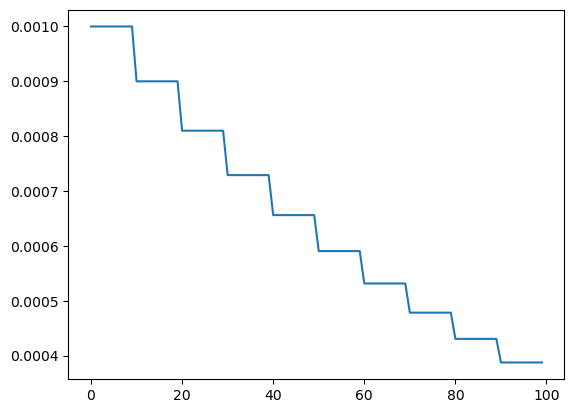

In [2]:
# 设置优化器，初始化学习率
optimizer = torch.optim.SGD(model.parameters(),lr=1e-3)
# 设置学习率调整策略
schedular = StepLR(optimizer=optimizer,step_size=10,gamma=0.9)
lr_his = schedular_lr(optimizer, schedular)


#### 自定义版本

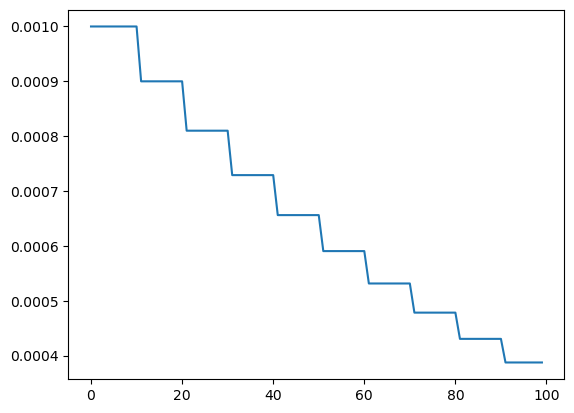

In [5]:
class CustomStepLR:
    def __init__(self, optimizer,step_size,gamma=0.9,last_epoch=-1):
        self.optimizer = optimizer
        self.step_size = step_size
        self.gamma = gamma
        self.last_epoch = last_epoch
        
    def get_lr(self):
        if (self.last_epoch==0) or (self.last_epoch%self.step_size!=0): # 只是获取当前的lr
            return [group['lr'] for group in self.optimizer.param_groups]
        return [group['lr'] * self.gamma for group in self.optimizer.param_groups]

    def step(self):
        self.last_epoch += 1
        lrs = self.get_lr()
        for param, lr in zip(self.optimizer.param_groups,lrs):
            param['lr'] = lr
        
optimizer2 = torch.optim.SGD(model.parameters(),lr=1e-3)
scheduler2 = CustomStepLR(optimizer2,step_size=10)
lr_his = schedular_lr(optimizer2, scheduler2)